In [41]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Base

In [2]:
base_path = Path('data/processed/base_final.parquet')
if not base_path.exists():
    base_path = Path('base_final.parquet')

base = pd.read_parquet(base_path)

In [3]:
base.head()

,subsystem_code,timestamp,load_mw,source_year,precipitation_mm,pressure_station_hpa,pressure_max_hpa,pressure_min_hpa,global_radiation_kj_m2,temperature_c,...,load_mean_3h,load_std_3h,load_mean_6h,load_std_6h,load_mean_24h,load_std_24h,ramp_1h,target_load_1h,target_load_6h,target_load_24h
0,NE,2022-01-08 00:00:00,11926.333,2022,0.520000,974.148148,974.203704,973.448148,47.800000,24.492593,...,12420.102000,134.929127,12237.736833,221.810606,11584.597667,583.661108,-244.169,11635.094,9793.342,11660.956
1,NE,2022-01-08 01:00:00,11635.094,2022,0.253333,973.319643,973.403571,972.975000,1.060000,24.185714,...,12233.397333,292.610669,12222.878833,241.764288,11583.075958,582.678831,-338.512,11402.214,9865.790,11290.670
2,NE,2022-01-08 02:00:00,11402.214,2022,0.238298,974.063793,974.348276,973.979310,16.883333,24.013793,...,11942.090667,315.171078,12139.194667,343.039821,11584.575750,582.768185,-291.239,11147.334,10122.028,11049.698
3,NE,2022-01-08 03:00:00,11147.334,2022,0.486957,973.198214,973.580357,973.164286,615.487500,23.726786,...,11654.547000,262.600449,12037.324500,459.007934,11585.088542,582.594832,-232.880,10927.972,10205.706,10924.900
4,NE,2022-01-08 04:00:00,10927.972,2022,0.195652,973.167273,973.587273,973.147273,426.871429,23.521818,...,11394.880667,243.962677,11814.139000,518.641087,11581.656042,585.017287,-254.880,10275.910,10321.871,10726.672


# Linear Regression

## Divisão da base

In [4]:
n = len(base)
print(f"Number of rows: {n}")

Number of rows: 40704


In [5]:
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = base.iloc[:train_end]
val   = base.iloc[train_end:val_end]
test  = base.iloc[val_end:]

print(len(train), len(val), len(test))

28492 6106 6106


In [6]:
print("Inicio e fim do conjunto de treino:", train['timestamp'].min(), train['timestamp'].max())
print("Inicio e fim do conjunto de validação:", val['timestamp'].min(), val['timestamp'].max())
print("Inicio e fim do conjunto de teste:", test['timestamp'].min(), test['timestamp'].max())

Inicio e fim do conjunto de treino: 2022-01-08 00:00:00 2025-04-09 03:00:00
Inicio e fim do conjunto de validação: 2025-04-09 04:00:00 2025-12-19 13:00:00
Inicio e fim do conjunto de teste: 2025-12-19 14:00:00 2026-08-30 23:00:00


## 1h

In [63]:
lista = base.columns.tolist()
print("Colunas do dataset:", lista)

Colunas do dataset: ['subsystem_code', 'timestamp', 'load_mw', 'source_year', 'precipitation_mm', 'pressure_station_hpa', 'pressure_max_hpa', 'pressure_min_hpa', 'global_radiation_kj_m2', 'temperature_c', 'dew_point_c', 'temperature_max_c', 'temperature_min_c', 'dew_point_max_c', 'dew_point_min_c', 'humidity_max_pct', 'humidity_min_pct', 'humidity_pct', 'wind_gust_ms', 'wind_speed_ms', 'wind_direction_deg', 'station_count', 'month', 'weekday', 'weekend', 'hour', 'weekday_num', 'is_holiday_national', 'states_on_holiday', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h', 'load_mean_3h', 'load_std_3h', 'load_mean_6h', 'load_std_6h', 'load_mean_24h', 'load_std_24h', 'ramp_1h', 'target_load_1h', 'target_load_6h', 'target_load_24h']


In [64]:
features_1 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national'
]

features_2 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw'
]

features_3 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h'
]

features_4 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
    'load_mean_3h',
    'load_mean_6h',
    'load_mean_24h',

    'load_std_3h',
    'load_std_6h',
    'load_std_24h',

    'ramp_1h'
]

features_5 = [
    'hour_sin',
        'hour_cos',
        'weekday_sin',
        'weekday_cos',
        'month_sin',
        'month_cos',
        'weekend',
        'is_holiday_national',
        'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
        'load_mean_3h',
        'load_mean_6h',
        'load_mean_24h',
    
        'load_std_3h',
        'load_std_6h',
        'load_std_24h',
    
        'ramp_1h',
        'precipitation_mm', 'pressure_station_hpa', 'global_radiation_kj_m2', 'temperature_c', 'humidity_pct', 'wind_gust_ms', 'wind_speed_ms'
]

target = 'target_load_1h'

In [65]:
def avaliar_modelo(features, nome):
    
    X_train = train[features]
    y_train = train['target_load_1h']

    X_val = val[features]
    y_val = val['target_load_1h']

    model = LinearRegression()

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    mape = mean_absolute_percentage_error(
        y_val,
        pred
    ) * 100

    print(
        f'{nome:<25} | '
        f'MAE: {mae:.2f} | '
        f'RMSE: {rmse:.2f} | '
        f'MAPE: {mape:.2f}%'
    )

    return model

In [66]:
model_1 = avaliar_modelo(
    features_1,
    'Linear - Calendário'
)

model_2 = avaliar_modelo(
    features_2,
    'Linear - + Carga'
)

model_3 = avaliar_modelo(
    features_3,
    'Linear - + Lags'
)

model_4 = avaliar_modelo(
    features_4,
    'Linear - + Rolling'
)

model_5 = avaliar_modelo(
    features_5,
    'Linear - + Meteorologia'
)

Linear - Calendário       | MAE: 1099.95 | RMSE: 1296.59 | MAPE: 8.19%
Linear - + Carga          | MAE: 229.93 | RMSE: 316.45 | MAPE: 1.76%
Linear - + Lags           | MAE: 213.96 | RMSE: 287.53 | MAPE: 1.63%
Linear - + Rolling        | MAE: 207.72 | RMSE: 273.10 | MAPE: 1.59%
Linear - + Meteorologia   | MAE: 204.85 | RMSE: 268.27 | MAPE: 1.57%


In [67]:
X_train = train[features_5]
y_train = train['target_load_1h']

model_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

model_scaled.fit(X_train, y_train)

coef = model_scaled.named_steps['regressor'].coef_

coeficientes = pd.DataFrame({
    'feature': features_5,
    'coeficiente': coef
})

coeficientes['abs_coef'] = coeficientes['coeficiente'].abs()

coeficientes = coeficientes.sort_values(
    'abs_coef',
    ascending=False
)

print(coeficientes)

                   feature  coeficiente     abs_coef
8                  load_mw  1974.690790  1974.690790
16            load_mean_6h  -279.690530   279.690530
17           load_mean_24h   275.959212   275.959212
27            wind_gust_ms   242.340494   242.340494
28           wind_speed_ms  -213.286054   213.286054
9              load_lag_1h  -169.999301   169.999301
21                 ramp_1h  -161.562029   161.562029
10             load_lag_2h  -130.618272   130.618272
15            load_mean_3h  -119.023132   119.023132
12            load_lag_24h   -82.042719    82.042719
6                  weekend   -57.967197    57.967197
24  global_radiation_kj_m2   -53.644651    53.644651
11             load_lag_3h   -50.545686    50.545686
25           temperature_c    49.346987    49.346987
1                 hour_cos   -47.900617    47.900617
26            humidity_pct   -37.931743    37.931743
20            load_std_24h    34.992755    34.992755
19             load_std_6h   -29.995972    29.

In [68]:
# Resíduos na validação: valor observado menos valor previsto (MW).
X_val_scaled = val[features_5]
pred_val_scaled = model_scaled.predict(X_val_scaled)

residuos_scaled = pd.DataFrame({
    'timestamp': val['timestamp'],
    'observado': val[target],
    'previsto': pred_val_scaled,
}, index=val.index)
residuos_scaled['residuo'] = (
    residuos_scaled['observado'] - residuos_scaled['previsto']
)

residuos_scaled.head()


,timestamp,observado,previsto,residuo
28492,2025-04-09 04:00:00,13268.071,13430.463950,-162.392950
28493,2025-04-09 05:00:00,12893.804,13137.337228,-243.533228
28494,2025-04-09 06:00:00,13391.710,12897.483528,494.226472
28495,2025-04-09 07:00:00,14051.591,13703.599700,347.991300
28496,2025-04-09 08:00:00,14175.506,14222.991874,-47.485874


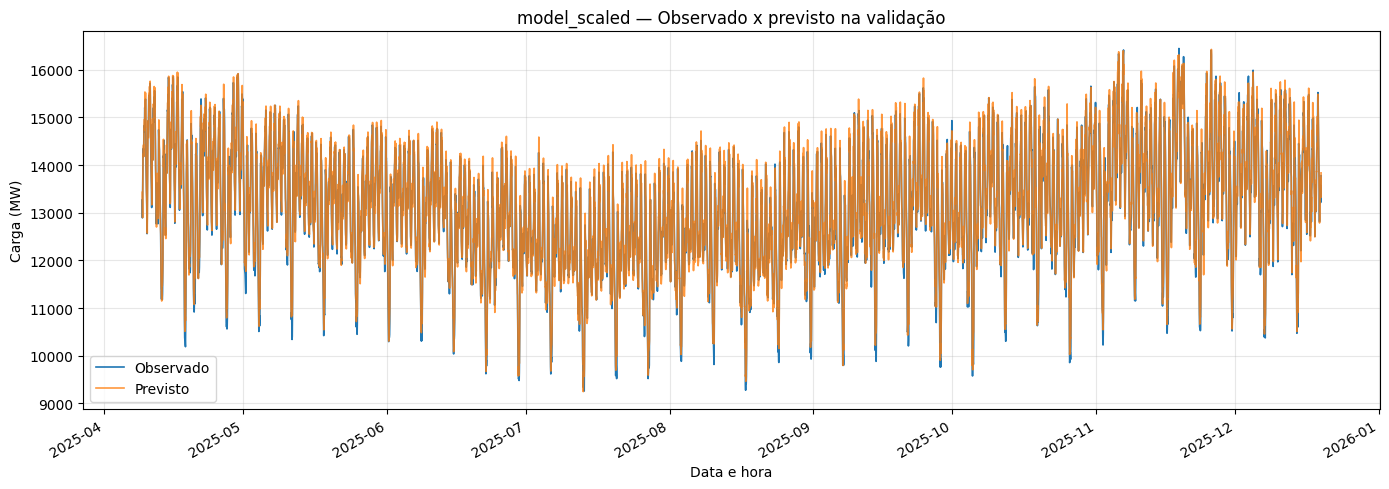

In [69]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['observado'],
    label='Observado', linewidth=1.2,
)
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['previsto'],
    label='Previsto', linewidth=1.2, alpha=0.8,
)
ax.set_title('model_scaled — Observado x previsto na validação')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


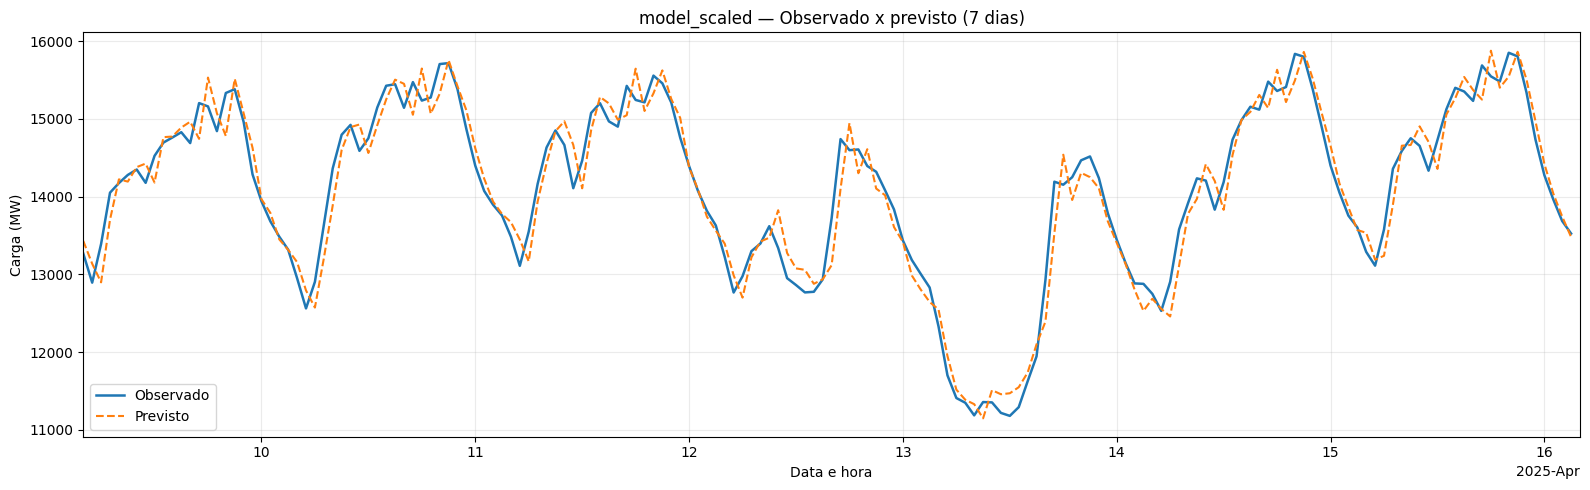

In [70]:
inicio_plot = pd.to_datetime(residuos_scaled['timestamp']).min()
dias_plot = 7
fim_plot = inicio_plot + pd.Timedelta(days=dias_plot)

dados_plot = residuos_scaled.copy()
dados_plot['timestamp'] = pd.to_datetime(dados_plot['timestamp'])
dados_plot = dados_plot.loc[
    (dados_plot['timestamp'] >= inicio_plot)
    & (dados_plot['timestamp'] < fim_plot)
].sort_values('timestamp')

if dados_plot.empty:
    raise ValueError('Não há dados no período selecionado. Ajuste inicio_plot ou dias_plot.')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    dados_plot['timestamp'], dados_plot['observado'],
    label='Observado', color='tab:blue', linewidth=1.8,
)
ax.plot(
    dados_plot['timestamp'], dados_plot['previsto'],
    label='Previsto', color='tab:orange', linewidth=1.5, linestyle='--',
)

limite_inferior = dados_plot[['observado', 'previsto']].min().min()
limite_superior = dados_plot[['observado', 'previsto']].max().max()
margem = max((limite_superior - limite_inferior) * 0.05, 1.0)
ax.set_ylim(limite_inferior - margem, limite_superior + margem)
ax.set_xlim(inicio_plot, fim_plot)
localizador = mdates.AutoDateLocator(minticks=5, maxticks=10)
ax.xaxis.set_major_locator(localizador)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(localizador))
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.set_title(f'model_scaled — Observado x previsto ({dias_plot} dias)')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


Horários com maior erro absoluto médio (MAE), em toda a validação:
Hora da carga prevista (t + 1h), conforme o relógio da base.
Viés positivo: previsão abaixo do observado; negativo: acima.


,quantidade,mae_mw,rmse_mw,vies_mw,maior_erro_absoluto_mw
hora,,,,,
12,255,431.71,453.99,-423.39,811.05
19,254,397.92,425.75,-396.59,964.62
18,254,372.13,424.72,366.26,1210.35
17,254,329.49,424.85,105.31,1260.47
21,254,292.25,335.00,280.38,874.37
7,255,280.08,338.52,143.13,1094.37
13,255,252.73,298.17,37.61,931.24
8,255,248.07,303.56,107.56,899.11
16,254,202.05,254.77,140.66,1126.44


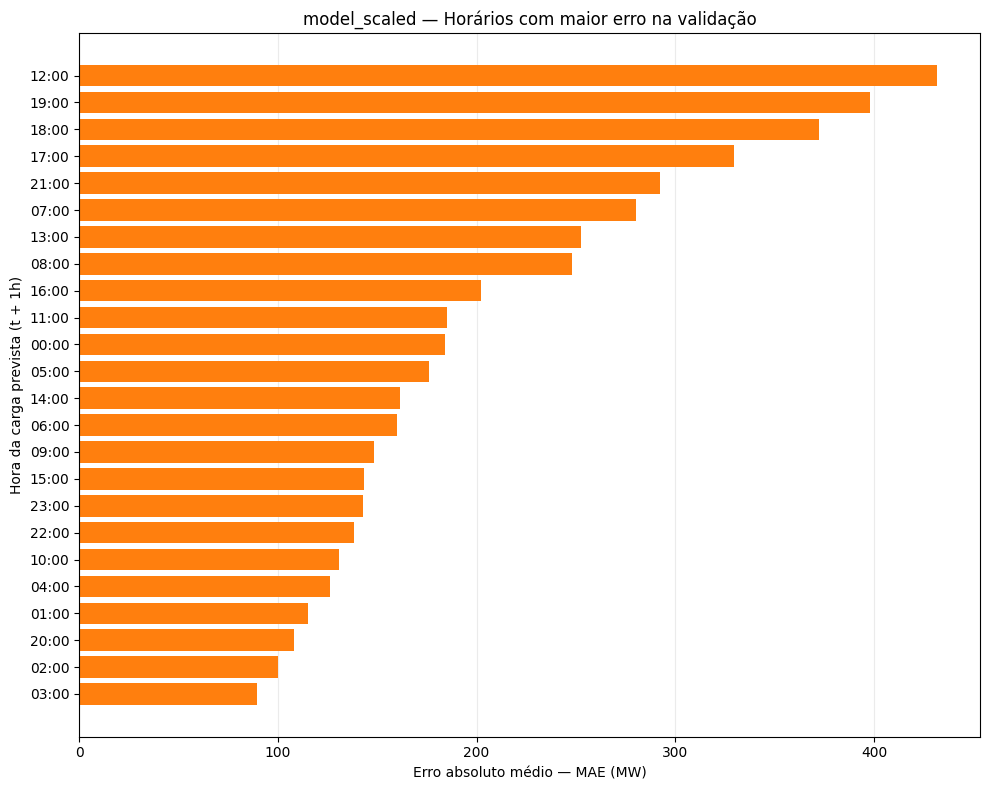

In [71]:
import matplotlib.pyplot as plt
from IPython.display import display

# Avalia toda a validação, agrupando pela hora da carga prevista (t + 1h).
erros_horarios_scaled = residuos_scaled.copy()
erros_horarios_scaled['hora'] = (
    pd.to_datetime(erros_horarios_scaled['timestamp']) + pd.Timedelta(hours=1)
).dt.hour
erros_horarios_scaled = erros_horarios_scaled.dropna(subset=['hora', 'residuo'])
erros_horarios_scaled['erro_absoluto'] = erros_horarios_scaled['residuo'].abs()
erros_horarios_scaled['erro_quadrado'] = erros_horarios_scaled['residuo'] ** 2

ranking_horarios_scaled = (
    erros_horarios_scaled.groupby('hora')
    .agg(
        quantidade=('residuo', 'count'),
        mae_mw=('erro_absoluto', 'mean'),
        mse_mw2=('erro_quadrado', 'mean'),
        vies_mw=('residuo', 'mean'),
        maior_erro_absoluto_mw=('erro_absoluto', 'max'),
    )
    .assign(rmse_mw=lambda tabela: np.sqrt(tabela['mse_mw2']))
    .drop(columns='mse_mw2')
    .sort_values(['mae_mw', 'hora'], ascending=[False, True])
)
ranking_horarios_scaled = ranking_horarios_scaled[
    ['quantidade', 'mae_mw', 'rmse_mw', 'vies_mw', 'maior_erro_absoluto_mw']
]

print('Horários com maior erro absoluto médio (MAE), em toda a validação:')
print('Hora da carga prevista (t + 1h), conforme o relógio da base.')
print('Viés positivo: previsão abaixo do observado; negativo: acima.')
display(ranking_horarios_scaled.round(2))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [f'{int(hora):02d}:00' for hora in ranking_horarios_scaled.index],
    ranking_horarios_scaled['mae_mw'],
    color='tab:orange',
)
ax.invert_yaxis()
ax.set_title('model_scaled — Horários com maior erro na validação')
ax.set_xlabel('Erro absoluto médio — MAE (MW)')
ax.set_ylabel('Hora da carga prevista (t + 1h)')
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## 6h

In [72]:
features_1 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national'
]

features_2 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw'
]

features_3 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h'
]

features_4 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
    'load_mean_3h',
    'load_mean_6h',
    'load_mean_24h',

    'load_std_3h',
    'load_std_6h',
    'load_std_24h',

    'ramp_1h'
]

features_5 = [
    'hour_sin',
        'hour_cos',
        'weekday_sin',
        'weekday_cos',
        'month_sin',
        'month_cos',
        'weekend',
        'is_holiday_national',
        'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
        'load_mean_3h',
        'load_mean_6h',
        'load_mean_24h',
    
        'load_std_3h',
        'load_std_6h',
        'load_std_24h',
    
        'ramp_1h',
        'precipitation_mm', 'pressure_station_hpa', 'global_radiation_kj_m2', 'temperature_c', 'humidity_pct', 'wind_gust_ms', 'wind_speed_ms'
]

target = 'target_load_6h'

In [73]:
def avaliar_modelo(features, nome):
    
    X_train = train[features]
    y_train = train['target_load_6h']

    X_val = val[features]
    y_val = val['target_load_6h']

    model = LinearRegression()

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    mape = mean_absolute_percentage_error(
        y_val,
        pred
    ) * 100

    print(
        f'{nome:<25} | '
        f'MAE: {mae:.2f} | '
        f'RMSE: {rmse:.2f} | '
        f'MAPE: {mape:.2f}%'
    )

    return model

In [74]:
model_6h_1 = avaliar_modelo(
    features_1,
    'Linear - Calendário'
)

model_6h_2 = avaliar_modelo(
    features_2,
    'Linear - + Carga'
)

model_6h_3 = avaliar_modelo(
    features_3,
    'Linear - + Lags'
)

model_6h_4 = avaliar_modelo(
    features_4,
    'Linear - + Rolling'
)

model_6h_5 = avaliar_modelo(
    features_5,
    'Linear - + Meteorologia'
)

Linear - Calendário       | MAE: 1092.91 | RMSE: 1285.68 | MAPE: 8.14%
Linear - + Carga          | MAE: 622.07 | RMSE: 827.06 | MAPE: 4.75%
Linear - + Lags           | MAE: 613.97 | RMSE: 795.62 | MAPE: 4.71%
Linear - + Rolling        | MAE: 482.57 | RMSE: 620.31 | MAPE: 3.80%
Linear - + Meteorologia   | MAE: 451.03 | RMSE: 586.75 | MAPE: 3.56%


In [75]:
X_train = train[features_5]
y_train = train['target_load_6h']

model_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

model_scaled.fit(X_train, y_train)

coef = model_scaled.named_steps['regressor'].coef_

coeficientes = pd.DataFrame({
    'feature': features_5,
    'coeficiente': coef
})

coeficientes['abs_coef'] = coeficientes['coeficiente'].abs()

coeficientes = coeficientes.sort_values(
    'abs_coef',
    ascending=False
)

print(coeficientes)

                   feature  coeficiente     abs_coef
17           load_mean_24h  1318.222777  1318.222777
8                  load_mw   928.809194   928.809194
16            load_mean_6h  -672.302300   672.302300
6                  weekend  -423.103573   423.103573
24  global_radiation_kj_m2   382.900651   382.900651
0                 hour_sin   347.911442   347.911442
12            load_lag_24h  -331.156590   331.156590
11             load_lag_3h  -228.492996   228.492996
20            load_std_24h   209.830608   209.830608
25           temperature_c   200.715476   200.715476
27            wind_gust_ms   153.061455   153.061455
7      is_holiday_national  -118.649976   118.649976
13            load_lag_48h   112.805631   112.805631
3              weekday_cos    88.036775    88.036775
28           wind_speed_ms   -87.044545    87.044545
18             load_std_3h   -84.221275    84.221275
15            load_mean_3h   -79.651158    79.651158
2              weekday_sin   -67.568048    67.

In [76]:
# Resíduos na validação: valor observado menos valor previsto (MW).
X_val_scaled = val[features_5]
pred_val_scaled = model_scaled.predict(X_val_scaled)

residuos_scaled = pd.DataFrame({
    'timestamp': val['timestamp'],
    'observado': val[target],
    'previsto': pred_val_scaled,
}, index=val.index)
residuos_scaled['residuo'] = (
    residuos_scaled['observado'] - residuos_scaled['previsto']
)

residuos_scaled.head()


,timestamp,observado,previsto,residuo
28492,2025-04-09 04:00:00,14280.053,13767.897447,512.155553
28493,2025-04-09 05:00:00,14349.609,13865.480637,484.128363
28494,2025-04-09 06:00:00,14178.355,13886.498143,291.856857
28495,2025-04-09 07:00:00,14525.764,14175.568685,350.195315
28496,2025-04-09 08:00:00,14696.861,14621.272544,75.588456


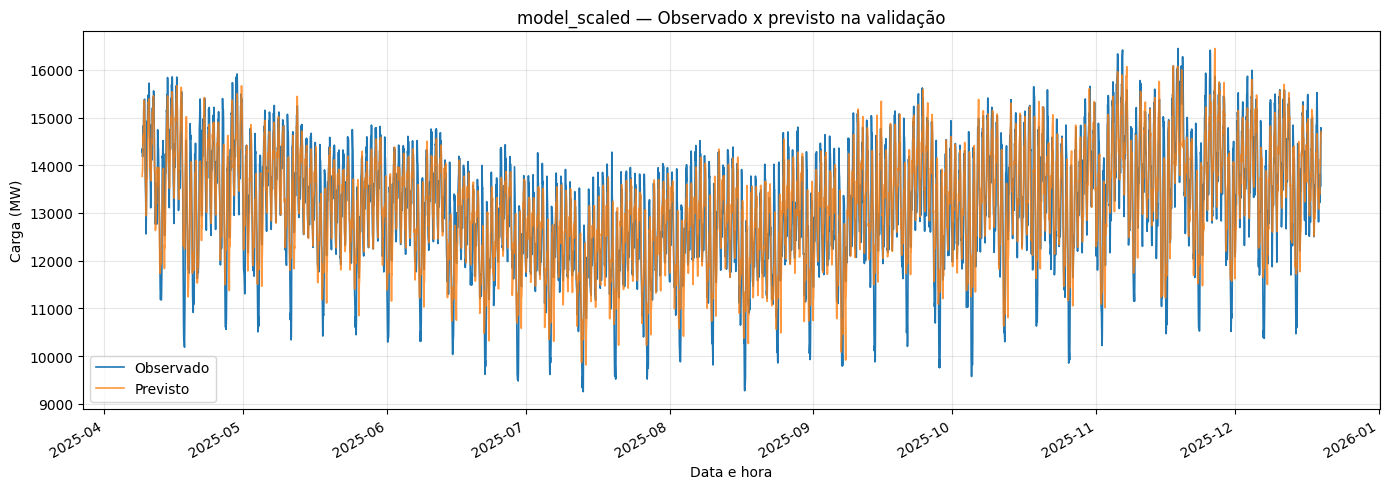

In [77]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['observado'],
    label='Observado', linewidth=1.2,
)
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['previsto'],
    label='Previsto', linewidth=1.2, alpha=0.8,
)
ax.set_title('model_scaled — Observado x previsto na validação')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


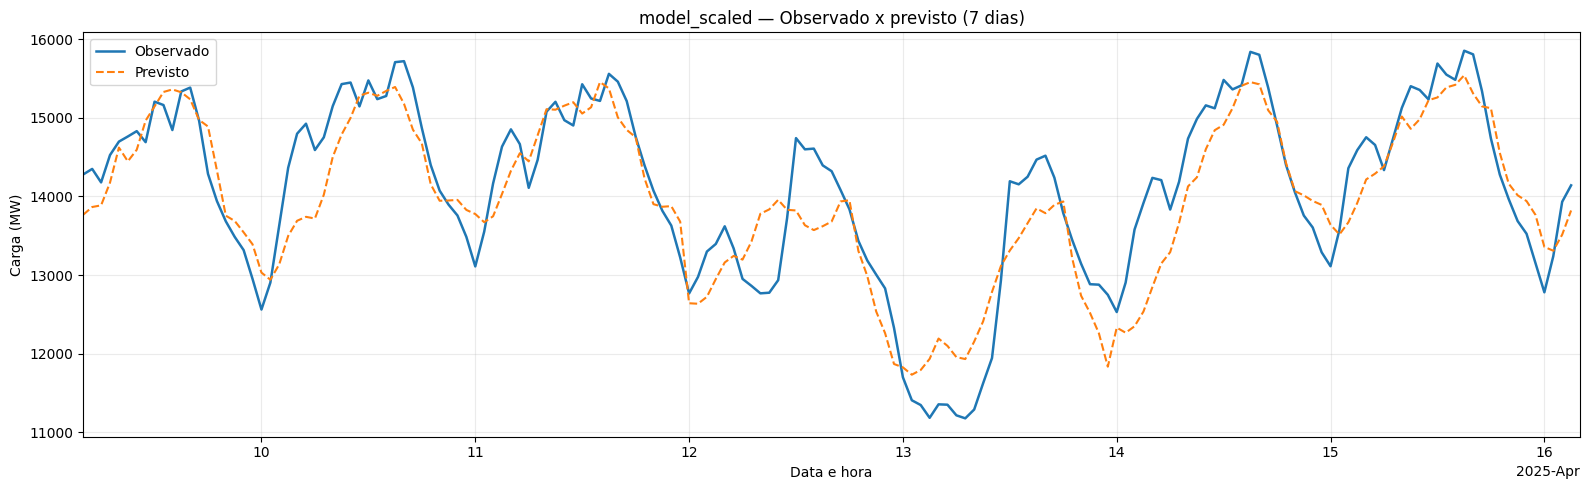

In [78]:
inicio_plot = pd.to_datetime(residuos_scaled['timestamp']).min()
dias_plot = 7
fim_plot = inicio_plot + pd.Timedelta(days=dias_plot)

dados_plot = residuos_scaled.copy()
dados_plot['timestamp'] = pd.to_datetime(dados_plot['timestamp'])
dados_plot = dados_plot.loc[
    (dados_plot['timestamp'] >= inicio_plot)
    & (dados_plot['timestamp'] < fim_plot)
].sort_values('timestamp')

if dados_plot.empty:
    raise ValueError('Não há dados no período selecionado. Ajuste inicio_plot ou dias_plot.')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    dados_plot['timestamp'], dados_plot['observado'],
    label='Observado', color='tab:blue', linewidth=1.8,
)
ax.plot(
    dados_plot['timestamp'], dados_plot['previsto'],
    label='Previsto', color='tab:orange', linewidth=1.5, linestyle='--',
)

limite_inferior = dados_plot[['observado', 'previsto']].min().min()
limite_superior = dados_plot[['observado', 'previsto']].max().max()
margem = max((limite_superior - limite_inferior) * 0.05, 1.0)
ax.set_ylim(limite_inferior - margem, limite_superior + margem)
ax.set_xlim(inicio_plot, fim_plot)
localizador = mdates.AutoDateLocator(minticks=5, maxticks=10)
ax.xaxis.set_major_locator(localizador)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(localizador))
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.set_title(f'model_scaled — Observado x previsto ({dias_plot} dias)')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


Horários com maior erro absoluto médio (MAE), em toda a validação:
Hora da carga prevista (t + 1h), conforme o relógio da base.
Viés positivo: previsão abaixo do observado; negativo: acima.


,quantidade,mae_mw,rmse_mw,vies_mw,maior_erro_absoluto_mw
hora,,,,,
17,255,734.55,864.59,707.54,2160.87
12,255,699.50,831.95,-632.12,2057.58
11,255,682.87,823.10,-594.37,2143.63
13,255,584.05,716.38,-506.75,1860.90
9,255,556.06,754.08,-102.80,2415.54
8,254,544.44,723.14,15.39,2243.84
10,255,539.02,704.31,-223.87,2364.03
7,254,538.84,661.39,213.31,1859.38
23,254,522.94,611.95,-467.55,1542.09


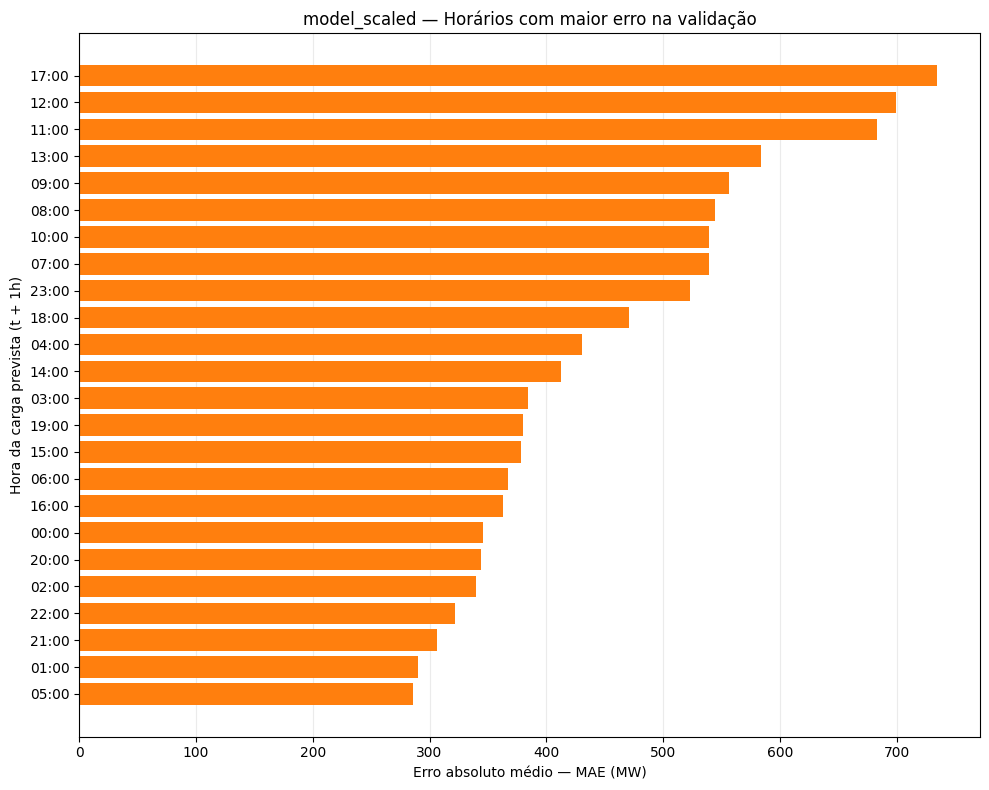

In [79]:
# Avalia toda a validação, agrupando pela hora da carga prevista (t + 1h).
erros_horarios_scaled = residuos_scaled.copy()
erros_horarios_scaled['hora'] = (
    pd.to_datetime(erros_horarios_scaled['timestamp']) + pd.Timedelta(hours=5)
).dt.hour
erros_horarios_scaled = erros_horarios_scaled.dropna(subset=['hora', 'residuo'])
erros_horarios_scaled['erro_absoluto'] = erros_horarios_scaled['residuo'].abs()
erros_horarios_scaled['erro_quadrado'] = erros_horarios_scaled['residuo'] ** 2

ranking_horarios_scaled = (
    erros_horarios_scaled.groupby('hora')
    .agg(
        quantidade=('residuo', 'count'),
        mae_mw=('erro_absoluto', 'mean'),
        mse_mw2=('erro_quadrado', 'mean'),
        vies_mw=('residuo', 'mean'),
        maior_erro_absoluto_mw=('erro_absoluto', 'max'),
    )
    .assign(rmse_mw=lambda tabela: np.sqrt(tabela['mse_mw2']))
    .drop(columns='mse_mw2')
    .sort_values(['mae_mw', 'hora'], ascending=[False, True])
)
ranking_horarios_scaled = ranking_horarios_scaled[
    ['quantidade', 'mae_mw', 'rmse_mw', 'vies_mw', 'maior_erro_absoluto_mw']
]

print('Horários com maior erro absoluto médio (MAE), em toda a validação:')
print('Hora da carga prevista (t + 1h), conforme o relógio da base.')
print('Viés positivo: previsão abaixo do observado; negativo: acima.')
display(ranking_horarios_scaled.round(2))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [f'{int(hora):02d}:00' for hora in ranking_horarios_scaled.index],
    ranking_horarios_scaled['mae_mw'],
    color='tab:orange',
)
ax.invert_yaxis()
ax.set_title('model_scaled — Horários com maior erro na validação')
ax.set_xlabel('Erro absoluto médio — MAE (MW)')
ax.set_ylabel('Hora da carga prevista (t + 1h)')
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## 24h

In [80]:
features_1 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national'
]

features_2 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw'
]

features_3 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h'
]

features_4 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
    'load_mean_3h',
    'load_mean_6h',
    'load_mean_24h',

    'load_std_3h',
    'load_std_6h',
    'load_std_24h',

    'ramp_1h'
]

features_5 = [
    'hour_sin',
        'hour_cos',
        'weekday_sin',
        'weekday_cos',
        'month_sin',
        'month_cos',
        'weekend',
        'is_holiday_national',
        'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
        'load_mean_3h',
        'load_mean_6h',
        'load_mean_24h',
    
        'load_std_3h',
        'load_std_6h',
        'load_std_24h',
    
        'ramp_1h',
        'precipitation_mm', 'pressure_station_hpa', 'global_radiation_kj_m2', 'temperature_c', 'humidity_pct', 'wind_gust_ms', 'wind_speed_ms'
]

target = 'target_load_24h'

In [81]:
def avaliar_modelo(features, nome):
    
    X_train = train[features]
    y_train = train['target_load_24h']

    X_val = val[features]
    y_val = val['target_load_24h']

    model = LinearRegression()

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    mape = mean_absolute_percentage_error(
        y_val,
        pred
    ) * 100

    print(
        f'{nome:<25} | '
        f'MAE: {mae:.2f} | '
        f'RMSE: {rmse:.2f} | '
        f'MAPE: {mape:.2f}%'
    )

    return model

In [82]:
model_24h_1 = avaliar_modelo(
    features_1,
    'Linear - Calendário'
)

model_24h_2 = avaliar_modelo(
    features_2,
    'Linear - + Carga'
)

model_24h_3 = avaliar_modelo(
    features_3,
    'Linear - + Lags'
)

model_24h_4 = avaliar_modelo(
    features_4,
    'Linear - + Rolling'
)

model_24h_5 = avaliar_modelo(
    features_5,
    'Linear - + Meteorologia'
)

Linear - Calendário       | MAE: 1118.43 | RMSE: 1306.26 | MAPE: 8.33%
Linear - + Carga          | MAE: 558.75 | RMSE: 775.76 | MAPE: 4.36%
Linear - + Lags           | MAE: 525.69 | RMSE: 710.27 | MAPE: 4.13%
Linear - + Rolling        | MAE: 493.15 | RMSE: 669.15 | MAPE: 3.91%
Linear - + Meteorologia   | MAE: 490.28 | RMSE: 664.06 | MAPE: 3.88%


In [83]:
X_train = train[features_5]
y_train = train['target_load_24h']

model_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

model_scaled.fit(X_train, y_train)

coef = model_scaled.named_steps['regressor'].coef_

coeficientes = pd.DataFrame({
    'feature': features_5,
    'coeficiente': coef
})

coeficientes['abs_coef'] = coeficientes['coeficiente'].abs()

coeficientes = coeficientes.sort_values(
    'abs_coef',
    ascending=False
)

print(coeficientes)

                   feature  coeficiente    abs_coef
8                  load_mw   747.958800  747.958800
13            load_lag_48h   431.160474  431.160474
17           load_mean_24h   420.022277  420.022277
3              weekday_cos   323.934895  323.934895
16            load_mean_6h  -291.511204  291.511204
2              weekday_sin   281.921847  281.921847
0                 hour_sin  -209.038168  209.038168
12            load_lag_24h  -195.122711  195.122711
11             load_lag_3h   150.408024  150.408024
20            load_std_24h   148.549877  148.549877
25           temperature_c   134.619587  134.619587
1                 hour_cos   134.127639  134.127639
24  global_radiation_kj_m2  -114.788862  114.788862
27            wind_gust_ms  -105.238251  105.238251
14           load_lag_168h    76.686557   76.686557
19             load_std_6h    66.055439   66.055439
23    pressure_station_hpa    63.130133   63.130133
28           wind_speed_ms    57.353826   57.353826
10          

In [84]:
# Resíduos na validação: valor observado menos valor previsto (MW).
X_val_scaled = val[features_5]
pred_val_scaled = model_scaled.predict(X_val_scaled)

residuos_scaled = pd.DataFrame({
    'timestamp': val['timestamp'],
    'observado': val[target],
    'previsto': pred_val_scaled,
}, index=val.index)
residuos_scaled['residuo'] = (
    residuos_scaled['observado'] - residuos_scaled['previsto']
)

residuos_scaled.head()


,timestamp,observado,previsto,residuo
28492,2025-04-09 04:00:00,13317.534,13574.188705,-256.654705
28493,2025-04-09 05:00:00,12950.658,13337.052412,-386.394412
28494,2025-04-09 06:00:00,12561.855,12998.989465,-437.134465
28495,2025-04-09 07:00:00,12904.483,13368.877643,-464.394643
28496,2025-04-09 08:00:00,13637.128,13825.220356,-188.092356


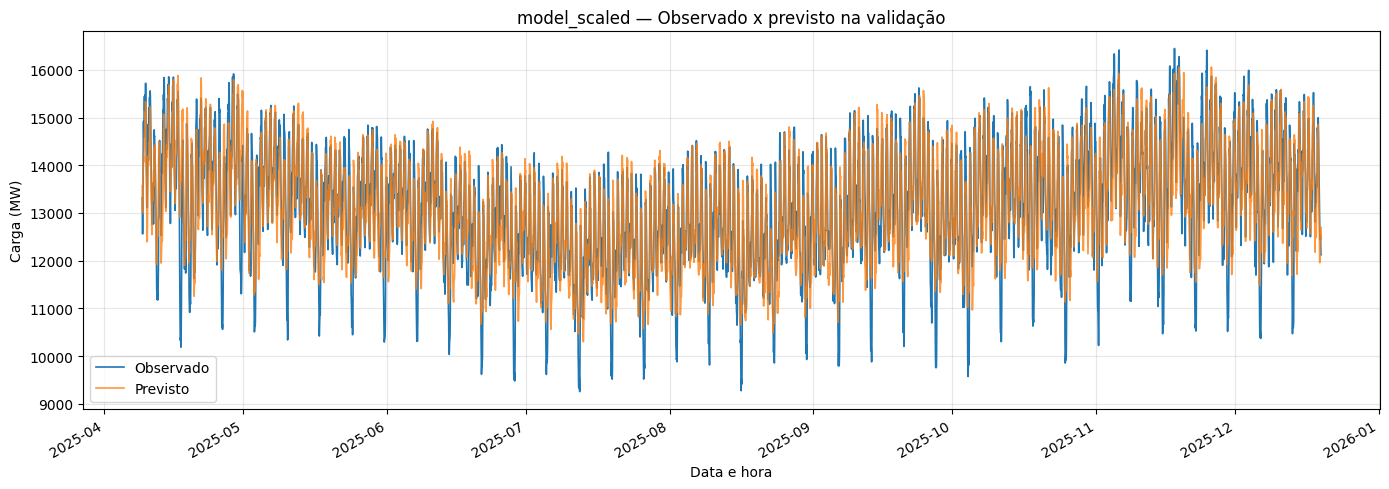

In [85]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['observado'],
    label='Observado', linewidth=1.2,
)
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['previsto'],
    label='Previsto', linewidth=1.2, alpha=0.8,
)
ax.set_title('model_scaled — Observado x previsto na validação')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


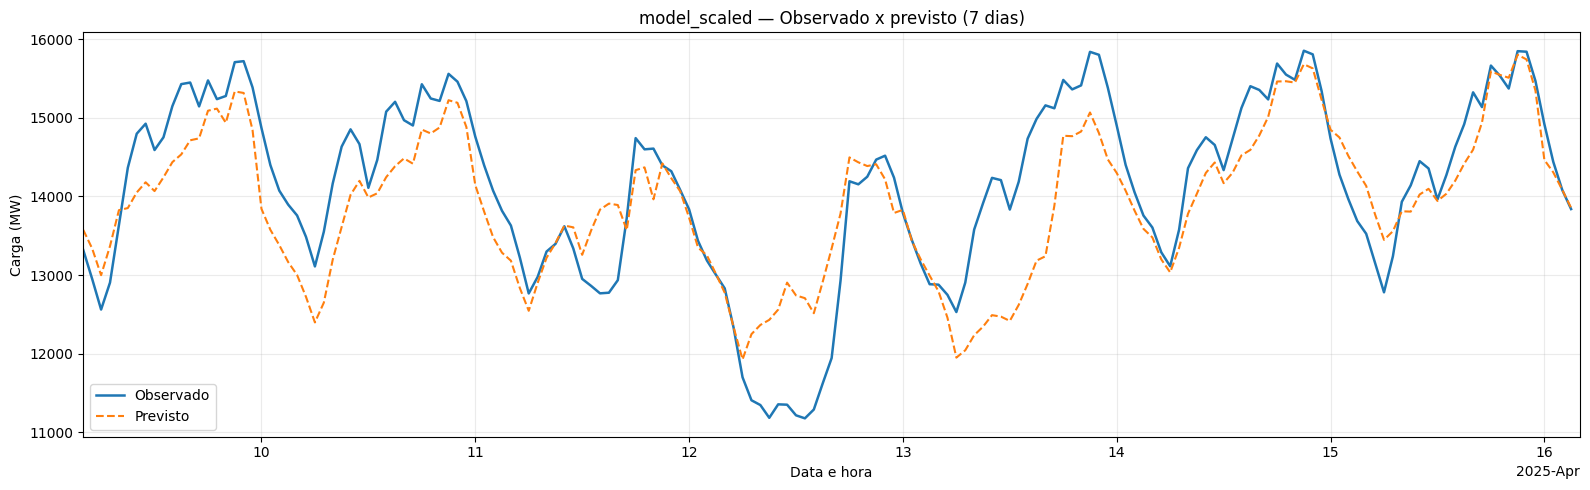

In [86]:
inicio_plot = pd.to_datetime(residuos_scaled['timestamp']).min()
dias_plot = 7
fim_plot = inicio_plot + pd.Timedelta(days=dias_plot)

dados_plot = residuos_scaled.copy()
dados_plot['timestamp'] = pd.to_datetime(dados_plot['timestamp'])
dados_plot = dados_plot.loc[
    (dados_plot['timestamp'] >= inicio_plot)
    & (dados_plot['timestamp'] < fim_plot)
].sort_values('timestamp')

if dados_plot.empty:
    raise ValueError('Não há dados no período selecionado. Ajuste inicio_plot ou dias_plot.')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    dados_plot['timestamp'], dados_plot['observado'],
    label='Observado', color='tab:blue', linewidth=1.8,
)
ax.plot(
    dados_plot['timestamp'], dados_plot['previsto'],
    label='Previsto', color='tab:orange', linewidth=1.5, linestyle='--',
)

limite_inferior = dados_plot[['observado', 'previsto']].min().min()
limite_superior = dados_plot[['observado', 'previsto']].max().max()
margem = max((limite_superior - limite_inferior) * 0.05, 1.0)
ax.set_ylim(limite_inferior - margem, limite_superior + margem)
ax.set_xlim(inicio_plot, fim_plot)
localizador = mdates.AutoDateLocator(minticks=5, maxticks=10)
ax.xaxis.set_major_locator(localizador)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(localizador))
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.set_title(f'model_scaled — Observado x previsto ({dias_plot} dias)')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


Horários com maior erro absoluto médio (MAE), em toda a validação:
Hora da carga prevista (t + 1h), conforme o relógio da base.
Viés positivo: previsão abaixo do observado; negativo: acima.


,quantidade,mae_mw,rmse_mw,vies_mw,maior_erro_absoluto_mw
hora,,,,,
14,254,803.85,1022.96,-116.22,3557.24
15,254,769.04,968.09,-64.04,3316.14
10,255,764.13,965.74,70.81,3428.59
9,255,755.88,947.70,113.18,3117.67
13,255,718.84,926.97,-137.00,3642.37
11,255,702.01,901.78,-28.60,3432.34
8,255,674.97,846.57,134.27,2728.24
16,254,637.50,804.21,-16.17,3057.19
12,255,624.23,823.24,-149.98,3414.22


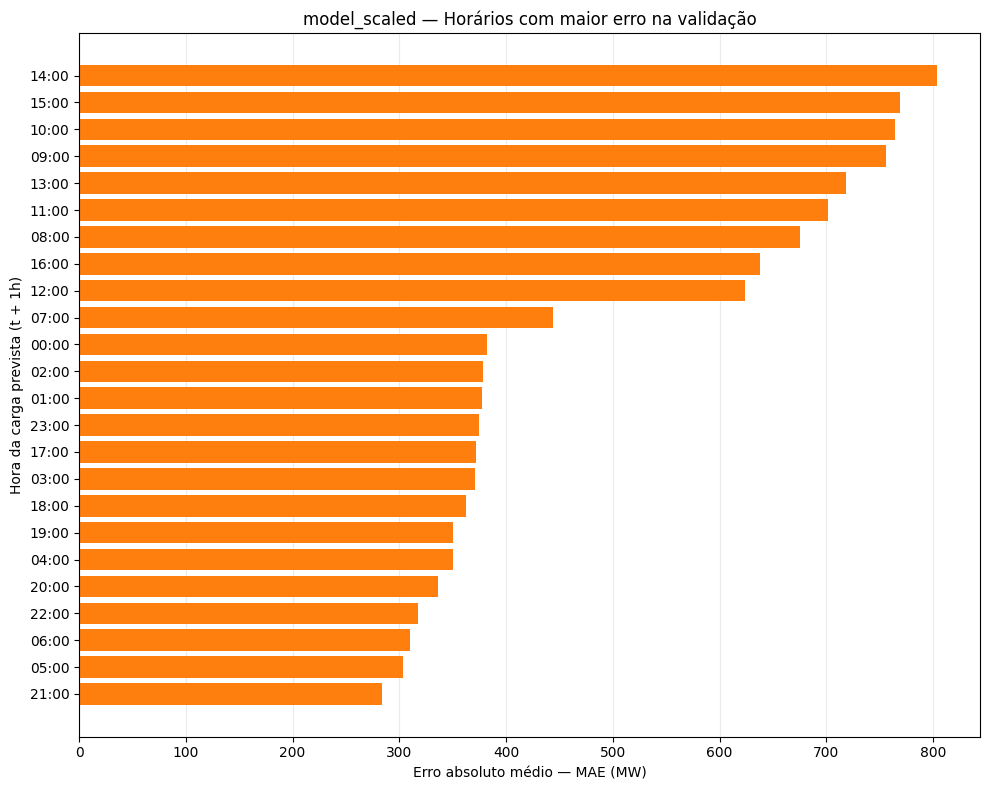

In [88]:
# Avalia toda a validação, agrupando pela hora da carga prevista (t + 1h).
erros_horarios_scaled = residuos_scaled.copy()
erros_horarios_scaled['hora'] = (
    pd.to_datetime(erros_horarios_scaled['timestamp']) + pd.Timedelta(hours=24)
).dt.hour
erros_horarios_scaled = erros_horarios_scaled.dropna(subset=['hora', 'residuo'])
erros_horarios_scaled['erro_absoluto'] = erros_horarios_scaled['residuo'].abs()
erros_horarios_scaled['erro_quadrado'] = erros_horarios_scaled['residuo'] ** 2

ranking_horarios_scaled = (
    erros_horarios_scaled.groupby('hora')
    .agg(
        quantidade=('residuo', 'count'),
        mae_mw=('erro_absoluto', 'mean'),
        mse_mw2=('erro_quadrado', 'mean'),
        vies_mw=('residuo', 'mean'),
        maior_erro_absoluto_mw=('erro_absoluto', 'max'),
    )
    .assign(rmse_mw=lambda tabela: np.sqrt(tabela['mse_mw2']))
    .drop(columns='mse_mw2')
    .sort_values(['mae_mw', 'hora'], ascending=[False, True])
)
ranking_horarios_scaled = ranking_horarios_scaled[
    ['quantidade', 'mae_mw', 'rmse_mw', 'vies_mw', 'maior_erro_absoluto_mw']
]

print('Horários com maior erro absoluto médio (MAE), em toda a validação:')
print('Hora da carga prevista (t + 1h), conforme o relógio da base.')
print('Viés positivo: previsão abaixo do observado; negativo: acima.')
display(ranking_horarios_scaled.round(2))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [f'{int(hora):02d}:00' for hora in ranking_horarios_scaled.index],
    ranking_horarios_scaled['mae_mw'],
    color='tab:orange',
)
ax.invert_yaxis()
ax.set_title('model_scaled — Horários com maior erro na validação')
ax.set_xlabel('Erro absoluto médio — MAE (MW)')
ax.set_ylabel('Hora da carga prevista (t + 1h)')
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## Resultados da regressão linear — horizontes de 1h, 6h e 24h

### Método e período avaliado

A análise compara cinco conjuntos cumulativos de variáveis para prever a carga do subsistema Nordeste em `t + 1h`, `t + 6h` e `t + 24h`:

1. **Calendário:** ciclos de hora, dia da semana e mês, fim de semana e feriado nacional.
2. **+ Carga:** acrescenta a carga atual (`load_mw`).
3. **+ Lags:** acrescenta cargas defasadas de 1, 2, 3, 24, 48 e 168 horas.
4. **+ Rolling:** acrescenta médias e desvios móveis de 3, 6 e 24 horas e a variação horária da carga (`ramp_1h`).
5. **+ Meteorologia:** acrescenta precipitação, pressão, radiação, temperatura, umidade e vento.

A divisão temporal usa **70% para treino (28.492 registros), 15% para validação (6.106) e 15% para teste (6.106)**. O treino vai de 08/01/2022 às 00h até 09/04/2025 às 03h; a validação, de 09/04/2025 às 04h até 19/12/2025 às 13h. As datas se referem ao instante de origem das previsões, conforme o relógio da base.

Os resultados abaixo são as **métricas de validação salvas nas células de avaliação**, sem padronização das variáveis. MAE é o erro absoluto médio; RMSE dá maior peso a erros grandes; ambos estão em MW. MAPE é o erro percentual absoluto médio. Valores menores indicam melhor desempenho.

### Previsão de 1h

| Variáveis | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| Calendário | 1.099,95 | 1.296,59 | 8,19 |
| + Carga | 229,93 | 316,45 | 1,76 |
| + Lags | 213,96 | 287,53 | 1,63 |
| + Rolling | 207,72 | 273,10 | 1,59 |
| + Meteorologia | 204,85 | 268,27 | 1,57 |

**Melhor configuração: + Meteorologia**, com redução de **81,38% no MAE** frente ao modelo de calendário. O ganho de MAE ao acrescentar meteorologia ao conjunto com rolling é de **1,38%**. A carga atual concentra o maior ganho: o MAE cai de 1.099,95 para 229,93 MW. Defasagens e estatísticas móveis refinam a previsão; o ganho adicional da meteorologia é menor.

### Previsão de 6h

| Variáveis | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| Calendário | 1.092,91 | 1.285,68 | 8,14 |
| + Carga | 622,07 | 827,06 | 4,75 |
| + Lags | 613,97 | 795,62 | 4,71 |
| + Rolling | 482,57 | 620,31 | 3,80 |
| + Meteorologia | 451,03 | 586,75 | 3,56 |

**Melhor configuração: + Meteorologia**, com redução de **58,73% no MAE** frente ao modelo de calendário. O ganho de MAE ao acrescentar meteorologia ao conjunto com rolling é de **6,54%**. As estatísticas móveis têm contribuição expressiva: reduzem o MAE em 21,40% em relação ao conjunto com lags. A meteorologia também melhora a previsão mais do que nos outros horizontes.

### Previsão de 24h

| Variáveis | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| Calendário | 1.118,43 | 1.306,26 | 8,33 |
| + Carga | 558,75 | 775,76 | 4,36 |
| + Lags | 525,69 | 710,27 | 4,13 |
| + Rolling | 493,15 | 669,15 | 3,91 |
| + Meteorologia | 490,28 | 664,06 | 3,88 |

**Melhor configuração: + Meteorologia**, com redução de **56,16% no MAE** frente ao modelo de calendário. O ganho de MAE ao acrescentar meteorologia ao conjunto com rolling é de **0,58%**. Defasagens e estatísticas móveis melhoram o resultado em relação ao uso da carga atual. A meteorologia produz um ganho adicional pequeno. O modelo completo tem o maior erro entre os três horizontes.

### Comparação das melhores configurações

| Horizonte | Melhor configuração | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---|---:|---:|---:|
| 1h | + Meteorologia | 204,85 | 268,27 | 1,57 |
| 6h | + Meteorologia | 451,03 | 586,75 | 3,56 |
| 24h | + Meteorologia | 490,28 | 664,06 | 3,88 |

A configuração completa apresenta o menor MAE, RMSE e MAPE em todos os horizontes. Seu MAE cresce de **204,85 MW em 1h** para **451,03 MW em 6h** e **490,28 MW em 24h**. Neste período, a previsão de 1h foi a mais precisa. A informação de carga melhora substancialmente o modelo de calendário em todos os casos; o ganho adicional da meteorologia é mais expressivo em 6h.

### Coeficientes do modelo padronizado (`model_scaled`)

As células com `StandardScaler` ajustam a configuração completa e permitem comparar a magnitude dos coeficientes na escala de um desvio padrão de cada variável:

| Horizonte | Variáveis com maiores coeficientes em valor absoluto | Coeficientes (MW) |
|---|---|---|
| 1h | `load_mw`; `load_mean_6h`; `load_mean_24h` | +1.974,69; −279,69; +275,96 |
| 6h | `load_mean_24h`; `load_mw`; `load_mean_6h` | +1.318,22; +928,81; −672,30 |
| 24h | `load_mw`; `load_lag_48h`; `load_mean_24h` | +747,96; +431,16; +420,02 |

A carga atual domina os coeficientes de 1h; em 6h, a média móvel de 24h tem a maior magnitude; em 24h, destacam-se carga atual, lag de 48h e média de 24h. Esses coeficientes descrevem associações condicionais no ajuste. Como cargas, lags e médias móveis são correlacionados, sua magnitude isolada não mede contribuição exclusiva nem efeito causal. A tabela de métricas anterior corresponde aos modelos sem padronização, enquanto os diagnósticos de resíduos abaixo correspondem a `model_scaled`.

### Horários com maior erro do modelo padronizado

O resíduo é **observado − previsto**. Viés positivo indica subestimação média; viés negativo indica superestimação média. Os três maiores MAEs por hora, em toda a validação, são:

| Horizonte | Hora da carga prevista | MAE (MW) | Viés médio (MW) |
|---|---|---:|---:|
| 1h | 12h | 431,71 | −423,39 |
| 1h | 19h | 397,92 | −396,59 |
| 1h | 18h | 372,13 | +366,26 |
| 6h | 18h | 734,55 | +707,54 |
| 6h | 13h | 699,50 | −632,12 |
| 6h | 12h | 682,87 | −594,37 |
| 24h | 14h | 803,85 | −116,22 |
| 24h | 15h | 769,04 | −64,04 |
| 24h | 10h | 764,13 | +70,81 |

**Correspondência dos horários:** as células atuais de ranking usam `timestamp + 1h` nos três horizontes. Para expressar a hora efetivamente prevista, esta tabela mantém os rótulos de 1h, soma 5 horas aos rótulos de 6h e soma 23 horas aos de 24h, com retorno ao início do dia quando necessário. Os valores de erro e viés são os registrados nas saídas; apenas a interpretação da hora foi ajustada aqui.

Em 1h, há superestimação média às 12h e 19h e subestimação às 18h. Em 6h, há subestimação às 18h e superestimação às 12h e 13h. Em 24h, os maiores erros aparecem às 14h, 15h e 10h; os vieses são menores em magnitude que os respectivos MAEs, indicando maior compensação entre erros positivos e negativos.

### Síntese

A regressão linear com todas as variáveis é a melhor configuração entre as cinco avaliadas em cada horizonte. O resultado de 1h se beneficia principalmente da carga atual; em 6h, estatísticas móveis e meteorologia trazem ganhos adicionais relevantes; em 24h, a meteorologia melhora pouco o conjunto com rolling. Os diagnósticos horários mostram que o desempenho varia durante o dia, mesmo na configuração completa.

Estas conclusões se referem ao período de validação. O conjunto de teste, de 19/12/2025 às 14h até 30/08/2026 às 23h, está separado no notebook, mas as análises resumidas aqui não apresentam métricas nesse conjunto.
